<a href="https://colab.research.google.com/github/Fahadqureshi0/AI-Customer-Support-Intent-Classifier/blob/main/Customer_Support_Intent_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing Tensorflow
!pip install Tensorflow

**Importing Dependencies**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

**Loading Dataset**

In [4]:
customer_support_dataset = pd.read_csv("/content/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

In [5]:
customer_support_dataset.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [6]:
# Shape of Dataset
customer_support_dataset.shape

(26872, 5)

In [8]:
# Value Counts of Intent Column
customer_support_dataset['intent'].value_counts()

,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


In [9]:
# Check for missing values
customer_support_dataset.isnull().sum()

,0
flags,0
instruction,0
category,0
intent,0
response,0


In [10]:
# Getting some info
customer_support_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


**Preparing Dataset**

In [11]:
X = customer_support_dataset['instruction']
Y = customer_support_dataset['intent']

**Label Encoder**

In [56]:
# Create LabelEncoder
label_encoder = LabelEncoder()

# Convert text labels to integers
Y_encoded = label_encoder.fit_transform(Y)


In [57]:
# Check the mapping
for number, intent in enumerate(label_encoder.classes_):
    print(number, "=", intent)

0 = cancel_order
1 = change_order
2 = change_shipping_address
3 = check_cancellation_fee
4 = check_invoice
5 = check_payment_methods
6 = check_refund_policy
7 = complaint
8 = contact_customer_service
9 = contact_human_agent
10 = create_account
11 = delete_account
12 = delivery_options
13 = delivery_period
14 = edit_account
15 = get_invoice
16 = get_refund
17 = newsletter_subscription
18 = payment_issue
19 = place_order
20 = recover_password
21 = registration_problems
22 = review
23 = set_up_shipping_address
24 = switch_account
25 = track_order
26 = track_refund


**Text Tokenizer**

In [58]:
# Raw customer messages
texts = customer_support_dataset["instruction"].astype(str)

# Create tokenizer
max_words = 5000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# IMPORTANT: fit tokenizer on RAW TEXT
tokenizer.fit_on_texts(texts)

# Convert text to numerical sequences
sequences = tokenizer.texts_to_sequences(texts)

# Padding
max_length = 50

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

print("X shape:", X.shape)
print("X dtype:", X.dtype)

X shape: (26872, 50)
X dtype: int32


**Train Test Split**

In [64]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=Y_encoded
)

**Building LSTM Model**

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

model = Sequential([

    Input(shape=(max_length,)),

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    LSTM(
        units=128,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(
        units=64
    ),

    Dropout(0.2),

    Dense(
        units=27,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 50, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,747 (3.14 MB)

 Trainable params: 822,747 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
from IPython.core import history
# Training Model
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.0599 - loss: 3.1123 - val_accuracy: 0.0755 - val_loss: 2.9763
Epoch 2/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 58s 86ms/step - accuracy: 0.1109 - loss: 2.7900 - val_accuracy: 0.1790 - val_loss: 2.4898
Epoch 3/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 58s 87ms/step - accuracy: 0.2682 - loss: 2.0466 - val_accuracy: 0.4184 - val_loss: 1.5286
Epoch 4/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 56s 83ms/step - accuracy: 0.5202 - loss: 1.2630 - val_accuracy: 0.6420 - val_loss: 0.9840
Epoch 5/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 83s 85ms/step - accuracy: 0.6613 - loss: 0.9379 - val_accuracy: 0.6990 - val_loss: 0.8550
Epoch 6/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.7114 - loss: 0.7933 - val_accuracy: 0.7200 - val_loss: 0.7593
Epoch 7/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.7279 - loss: 0.7373 - val_accuracy: 0.7273 - val_loss: 0.7349
Epoch 8/10
672/672 ━━━━━━━━━━━━━━━━━━━━ 57s 85ms/step - accuracy: 0.7266 - loss: 0.7336 - 

In [75]:
# Model Evaluation
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7650 - loss: 0.5848
Test Loss: 0.5848
Test Accuracy: 76.50%


In [76]:
# F1 Score
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


In [78]:
print(f1_score(Y_test, y_pred_classes, average='weighted'))

0.7376664772858851


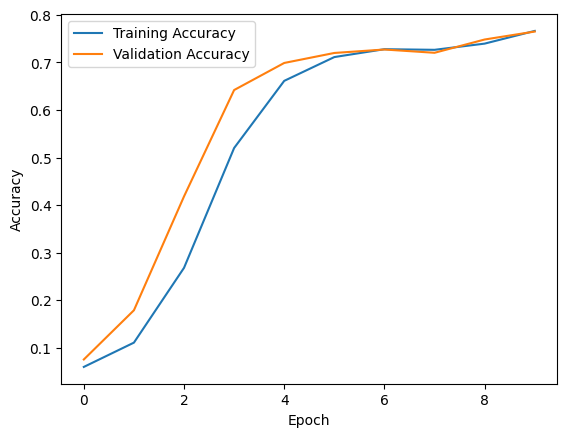

In [79]:
# Training Accuray Plots
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

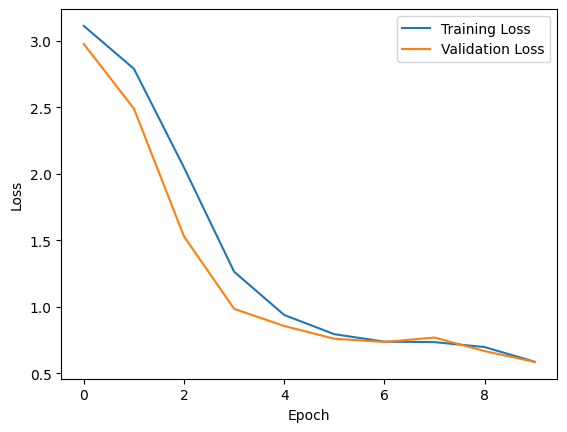

In [80]:
# Loass Accuracy
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Predicitve System**

In [110]:
def predict_intent(message):

    sequence = tokenizer.texts_to_sequences([message])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    prediction = model.predict(
        padded_sequence,
        verbose=0
    )[0]

    # Get top 3 predictions
    top_indices = np.argsort(prediction)[-3:][::-1]

    print("\nTop Predictions:")

    for index in top_indices:
        intent = label_encoder.inverse_transform([index])[0]
        confidence = prediction[index]

        print(
            f"{intent}: {confidence:.2%}"
        )

    # Best prediction
    predicted_index = np.argmax(prediction)

    confidence = float(
        prediction[predicted_index]
    )

    intent = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    return intent, confidence

In [111]:
import random

def get_response(intent):

    professional_responses = {

        "track_order": [
            "Certainly. I’d be happy to help you track your order. Please provide your order number so I can assist you with the latest delivery status.",
            "Of course. I can help you check your order status. Please provide your order number, and we’ll assist you with tracking your shipment.",
            "Certainly. Your order can be tracked using your order number. Please provide the order number so we can help you check its current status."
        ],

        "password_reset": [
            "Certainly. You can reset your password by selecting the 'Forgot Password' option on the login page. Follow the instructions provided to create a new password.",
            "I’d be happy to help you reset your password. Please select 'Forgot Password' on the login page and follow the instructions to securely update your password."
        ],

        "payment_failed": [
            "I’m sorry you’re experiencing difficulty with your payment. Please verify your payment details and ensure that your card has sufficient funds. If the issue persists, please contact your bank or payment provider.",
            "I understand that your payment was unsuccessful. Please verify your card details and available balance before trying again. If the problem continues, we’ll be happy to assist you further."
        ],

        "refund": [
            "Certainly. I can help you with your refund request. Please provide your order number so we can review the transaction and guide you through the refund process.",
            "I’d be happy to assist you with your refund. Please provide your order number, and we can help you with the next steps."
        ],

        "cancel_order": [
            "Certainly. I can help you with your order cancellation. Please provide your order number so we can check whether the order is still eligible for cancellation.",
            "I understand that you’d like to cancel your order. Please provide your order number so we can verify its current status and assist you accordingly."
        ],

        "shipping": [
            "Certainly. Standard delivery typically takes between 3 and 7 business days. Delivery times may vary depending on your location and shipping method.",
            "I’d be happy to provide information about your shipment. Delivery generally takes 3 to 7 business days, depending on the destination and selected shipping method."
        ],

        "change_address": [
            "Certainly. We can help you update your delivery address. Please provide your order number so we can check whether the address can still be changed.",
            "I’d be happy to help you update your delivery address. Please note that changes may not be possible once an order has been shipped."
        ],

        "account_locked": [
            "I understand that you’re having trouble accessing your account. Your account may have been temporarily locked for security reasons. Please try again after some time or contact our support team for further assistance."
        ],

        "greeting": [
            "Hello! Welcome to our customer support service. How may I assist you today?",
            "Hello! It’s a pleasure to assist you. How may I help you today?"
        ],

        "goodbye": [
            "Thank you for contacting customer support. Have a wonderful day!",
            "Thank you for reaching out to us. We appreciate your time and hope you have a great day!"
        ]
    }

    if intent in professional_responses:
        return random.choice(professional_responses[intent])

    return (
        "Thank you for contacting customer support. "
        "I’m happy to assist you. Could you please provide "
        "a few more details about your request?"
    )

In [112]:
def customer_support(message):

    intent, confidence = predict_intent(message)

    if confidence < 0.30:

        return {
            "intent": "unknown",
            "confidence": confidence,
            "response": (
                "Sorry, I couldn't understand your request. "
                "Could you please explain your problem?"
            )
        }

    response = get_response(intent)

    return {
        "intent": intent,
        "confidence": confidence,
        "response": response
    }

In [113]:
message = "I forgot my password"

result = customer_support(message)

print("\nCustomer:", message)
print("Predicted Intent:", result["intent"])
print("Confidence:", f"{result['confidence']:.2%}")
print("AI:", result["response"])


Top Predictions:
recover_password: 99.28%
delivery_period: 0.30%
create_account: 0.14%

Customer: I forgot my password
Predicted Intent: recover_password
Confidence: 99.28%
AI: Thank you for contacting customer support. I’m happy to assist you. Could you please provide a few more details about your request?
